# 第23章: 判別分析

## 学習目標
- 線形判別分析 (LDA) を理解し適用できる
- 二次判別分析 (QDA) を理解できる
- フィッシャーの判別関数を導出できる
- 分類誤差率を評価できる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 23.1 判別分析の概要

### 目的
説明変数 $\mathbf{x}$ を用いて、観測値がどのグループに属するかを予測

### 判別分析の種類
1. **線形判別分析 (LDA)**: グループ間で共分散行列が等しいと仮定
2. **二次判別分析 (QDA)**: グループごとに異なる共分散行列を許容

判別分析の基本概念

クラス1: n1 = 100, 平均 = [0, 0]
クラス2: n2 = 100, 平均 = [2, 2]


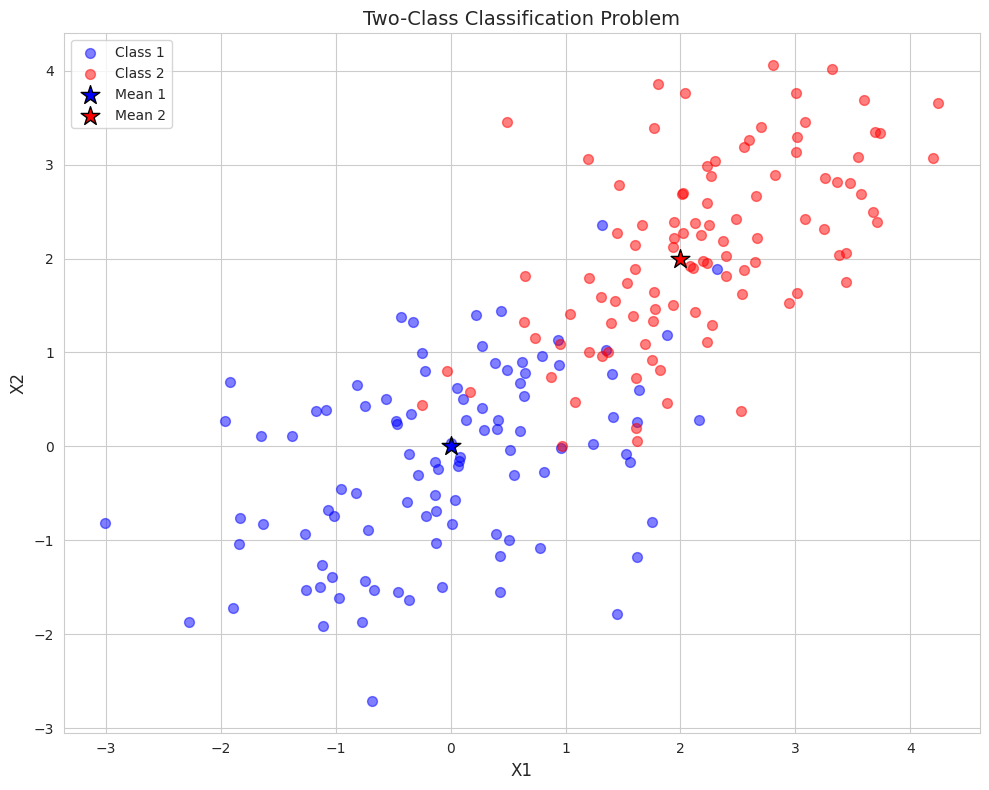

In [2]:
# データ生成と可視化
np.random.seed(123)

# Generate two-class data
n1, n2 = 100, 100

# Class 1
mean1 = [0, 0]
cov1 = [[1, 0.5], [0.5, 1]]
X1 = np.random.multivariate_normal(mean1, cov1, n1)

# Class 2
mean2 = [2, 2]
cov2 = [[1, 0.5], [0.5, 1]]  # Same covariance for LDA
X2 = np.random.multivariate_normal(mean2, cov2, n2)

# Combine data
X = np.vstack([X1, X2])
y = np.array([0]*n1 + [1]*n2)

print("判別分析の基本概念")
print("="*50)
print(f"\nクラス1: n1 = {n1}, 平均 = {mean1}")
print(f"クラス2: n2 = {n2}, 平均 = {mean2}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X1[:, 0], X1[:, 1], c='blue', alpha=0.5, label='Class 1', s=50)
ax.scatter(X2[:, 0], X2[:, 1], c='red', alpha=0.5, label='Class 2', s=50)
ax.scatter(*mean1, c='blue', s=200, marker='*', edgecolor='black', label='Mean 1')
ax.scatter(*mean2, c='red', s=200, marker='*', edgecolor='black', label='Mean 2')
ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title('Two-Class Classification Problem', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 23.2 線形判別分析 (LDA)

### 仮定
- 各クラスの分布は多変量正規分布
- 共分散行列は全クラスで同一: $\boldsymbol{\Sigma}_1 = \boldsymbol{\Sigma}_2 = \boldsymbol{\Sigma}$

### 判別関数
2クラスの場合、線形判別関数:
$$L(\mathbf{x}) = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - \frac{1}{2}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1} (\boldsymbol{\mu}_1 + \boldsymbol{\mu}_2)$$

### 判別規則
- $L(\mathbf{x}) > \log(\pi_2/\pi_1)$ ならクラス1
- そうでなければクラス2

ここで $\pi_k$ はクラス $k$ の事前確率

In [3]:
# LDAの実装（手計算）
print("線形判別分析 (LDA)")
print("="*60)

# Calculate class means
mu1 = np.mean(X1, axis=0)
mu2 = np.mean(X2, axis=0)

# Calculate pooled covariance matrix
S1 = np.cov(X1.T)
S2 = np.cov(X2.T)
S_pooled = ((n1-1)*S1 + (n2-1)*S2) / (n1 + n2 - 2)

print("\nクラス平均:")
print(f"  μ_1 = {mu1}")
print(f"  μ_2 = {mu2}")

print("\nプール共分散行列:")
print(S_pooled)

# Calculate discriminant function coefficients
S_inv = np.linalg.inv(S_pooled)
w = S_inv @ (mu1 - mu2)
c = -0.5 * (mu1 - mu2) @ S_inv @ (mu1 + mu2)

print("\n判別関数: L(x) = w'x + c")
print(f"  w = {w}")
print(f"  c = {c:.4f}")
print("\n判別規則: L(x) > 0 ならクラス1, そうでなければクラス2")

線形判別分析 (LDA)

クラス平均:
  μ_1 = [-0.05168813 -0.17498362]
  μ_2 = [2.17017825 2.09394851]

プール共分散行列:
[[0.98864293 0.47485394]
 [0.47485394 0.96129351]]

判別関数: L(x) = w'x + c
  w = [-1.46015908 -1.63901019]
  c = 3.1193

判別規則: L(x) > 0 ならクラス1, そうでなければクラス2



sklearnによるLDA:
訓練精度: 91.0%


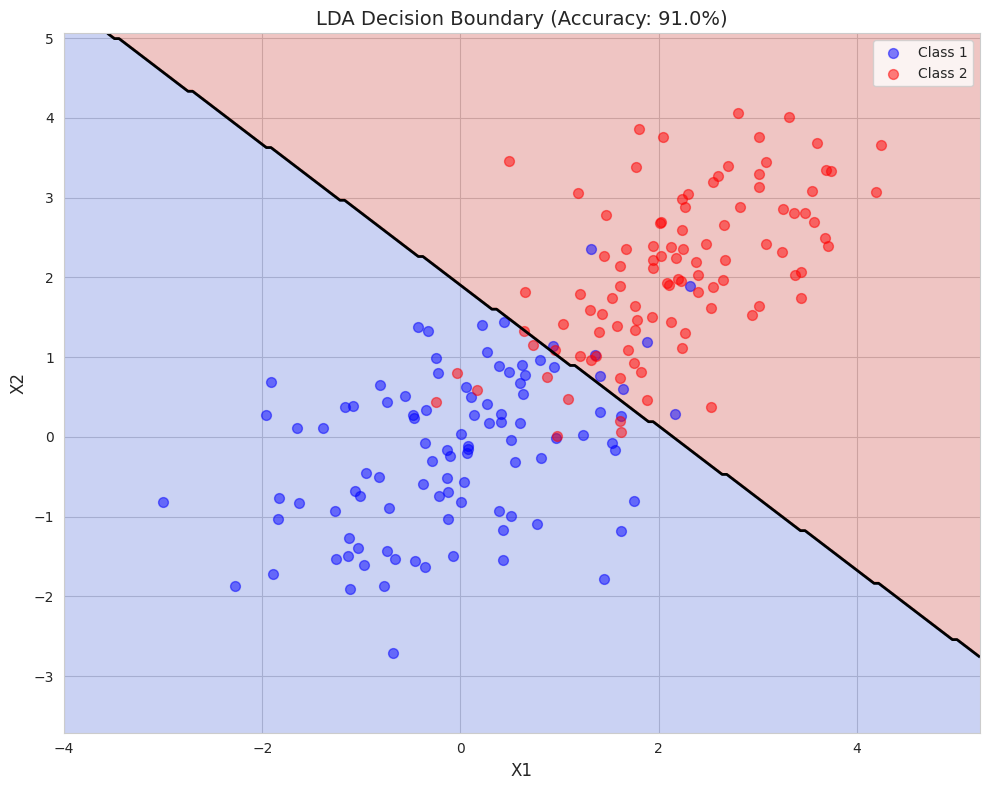

In [4]:
# LDA using sklearn
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

# Predict
y_pred_lda = lda.predict(X)

# Accuracy
accuracy_lda = np.mean(y_pred_lda == y)
print(f"\nsklearnによるLDA:")
print(f"訓練精度: {accuracy_lda:.1%}")

# Visualize decision boundary
fig, ax = plt.subplots(figsize=(10, 8))

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on mesh
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.scatter(X1[:, 0], X1[:, 1], c='blue', alpha=0.5, label='Class 1', s=50)
ax.scatter(X2[:, 0], X2[:, 1], c='red', alpha=0.5, label='Class 2', s=50)

# Plot decision boundary
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title(f'LDA Decision Boundary (Accuracy: {accuracy_lda:.1%})', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 23.3 二次判別分析 (QDA)

### 仮定
- 各クラスの分布は多変量正規分布
- 共分散行列はクラスごとに異なる: $\boldsymbol{\Sigma}_1 \neq \boldsymbol{\Sigma}_2$

### 判別関数
二次判別関数:
$$Q_k(\mathbf{x}) = -\frac{1}{2}\log|\boldsymbol{\Sigma}_k| - \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) + \log \pi_k$$

### 判別規則
$Q_k(\mathbf{x})$ が最大となるクラス $k$ に分類

In [5]:
# QDAが適切なデータを生成
np.random.seed(456)

# Class 1: small variance
mean1_qda = [0, 0]
cov1_qda = [[0.5, 0], [0, 0.5]]
X1_qda = np.random.multivariate_normal(mean1_qda, cov1_qda, n1)

# Class 2: large variance
mean2_qda = [2, 2]
cov2_qda = [[2, 0.5], [0.5, 2]]
X2_qda = np.random.multivariate_normal(mean2_qda, cov2_qda, n2)

X_qda = np.vstack([X1_qda, X2_qda])
y_qda = np.array([0]*n1 + [1]*n2)

print("二次判別分析 (QDA)")
print("="*60)
print("\n異なる共分散行列を持つデータ:")
print(f"\nクラス1の共分散行列:")
print(np.array(cov1_qda))
print(f"\nクラス2の共分散行列:")
print(np.array(cov2_qda))

二次判別分析 (QDA)

異なる共分散行列を持つデータ:

クラス1の共分散行列:
[[0.5 0. ]
 [0.  0.5]]

クラス2の共分散行列:
[[2.  0.5]
 [0.5 2. ]]



比較:
LDA精度: 90.5%
QDA精度: 92.0%


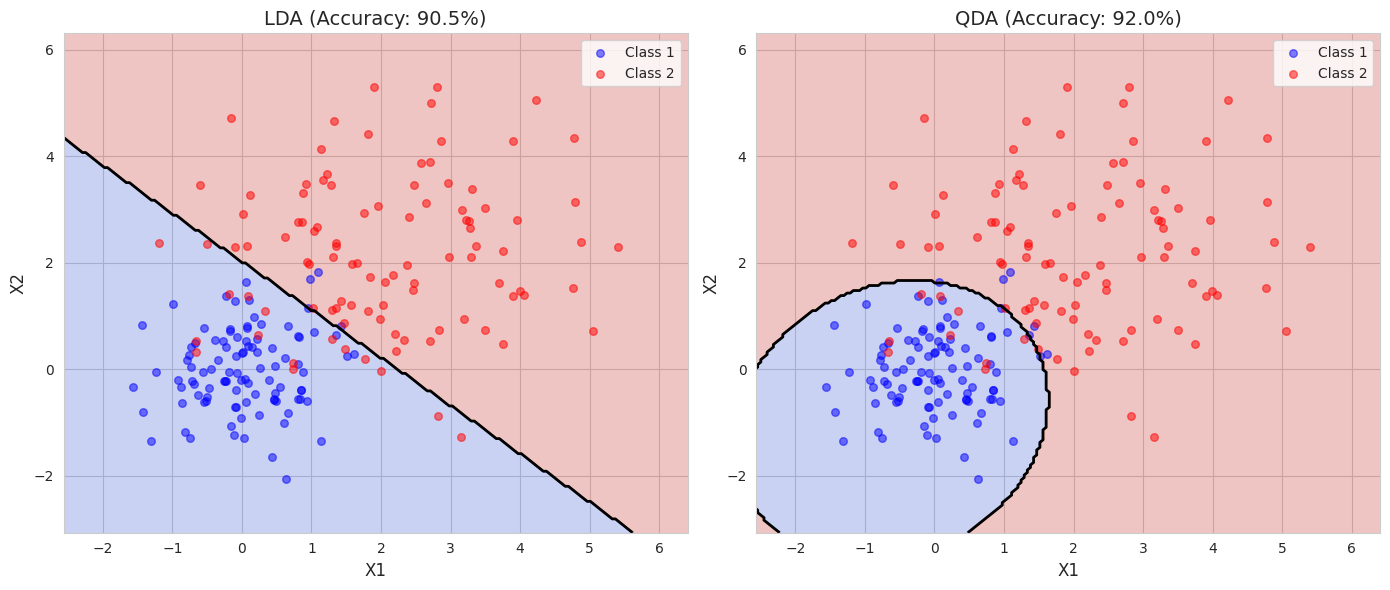

In [6]:
# Compare LDA and QDA
lda_qda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

lda_qda.fit(X_qda, y_qda)
qda.fit(X_qda, y_qda)

y_pred_lda_qda = lda_qda.predict(X_qda)
y_pred_qda = qda.predict(X_qda)

accuracy_lda_qda = np.mean(y_pred_lda_qda == y_qda)
accuracy_qda = np.mean(y_pred_qda == y_qda)

print(f"\n比較:")
print(f"LDA精度: {accuracy_lda_qda:.1%}")
print(f"QDA精度: {accuracy_qda:.1%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create mesh grid
x_min, x_max = X_qda[:, 0].min() - 1, X_qda[:, 0].max() + 1
y_min, y_max = X_qda[:, 1].min() - 1, X_qda[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

for ax, model, name, acc in [(axes[0], lda_qda, 'LDA', accuracy_lda_qda),
                              (axes[1], qda, 'QDA', accuracy_qda)]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X1_qda[:, 0], X1_qda[:, 1], c='blue', alpha=0.5, label='Class 1', s=30)
    ax.scatter(X2_qda[:, 0], X2_qda[:, 1], c='red', alpha=0.5, label='Class 2', s=30)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    ax.set_xlabel('X1', fontsize=12)
    ax.set_ylabel('X2', fontsize=12)
    ax.set_title(f'{name} (Accuracy: {acc:.1%})', fontsize=14)
    ax.legend()

plt.tight_layout()
plt.show()

## 23.4 フィッシャーの判別関数

### フィッシャーの基準
クラス間分散を最大化し、クラス内分散を最小化する方向を見つける

$$J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$$

### クラス間散布行列
$$\mathbf{S}_B = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T$$

### クラス内散布行列
$$\mathbf{S}_W = \sum_{i \in C_1}(\mathbf{x}_i - \boldsymbol{\mu}_1)(\mathbf{x}_i - \boldsymbol{\mu}_1)^T + \sum_{i \in C_2}(\mathbf{x}_i - \boldsymbol{\mu}_2)(\mathbf{x}_i - \boldsymbol{\mu}_2)^T$$

### 最適解
$$\mathbf{w}^* = \mathbf{S}_W^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$$

In [7]:
# フィッシャーの判別関数の実装
print("フィッシャーの判別関数")
print("="*60)

# Calculate class means
mu1_f = np.mean(X1, axis=0)
mu2_f = np.mean(X2, axis=0)

# Calculate within-class scatter matrix
S_W = np.zeros((2, 2))
for x in X1:
    diff = (x - mu1_f).reshape(-1, 1)
    S_W += diff @ diff.T
for x in X2:
    diff = (x - mu2_f).reshape(-1, 1)
    S_W += diff @ diff.T

# Calculate between-class scatter matrix
diff_means = (mu1_f - mu2_f).reshape(-1, 1)
S_B = diff_means @ diff_means.T

# Optimal projection direction
w_fisher = np.linalg.inv(S_W) @ (mu1_f - mu2_f)
w_fisher = w_fisher / np.linalg.norm(w_fisher)  # Normalize

print("\nクラス内散布行列 S_W:")
print(S_W)

print("\nクラス間散布行列 S_B:")
print(S_B)

print(f"\n最適射影方向: w = {w_fisher}")

フィッシャーの判別関数

クラス内散布行列 S_W:
[[195.7513007   94.0210792 ]
 [ 94.0210792  190.33611436]]

クラス間散布行列 S_B:
[[4.93669025 5.04126405]
 [5.04126405 5.14805303]]

最適射影方向: w = [-0.66519334 -0.74667116]


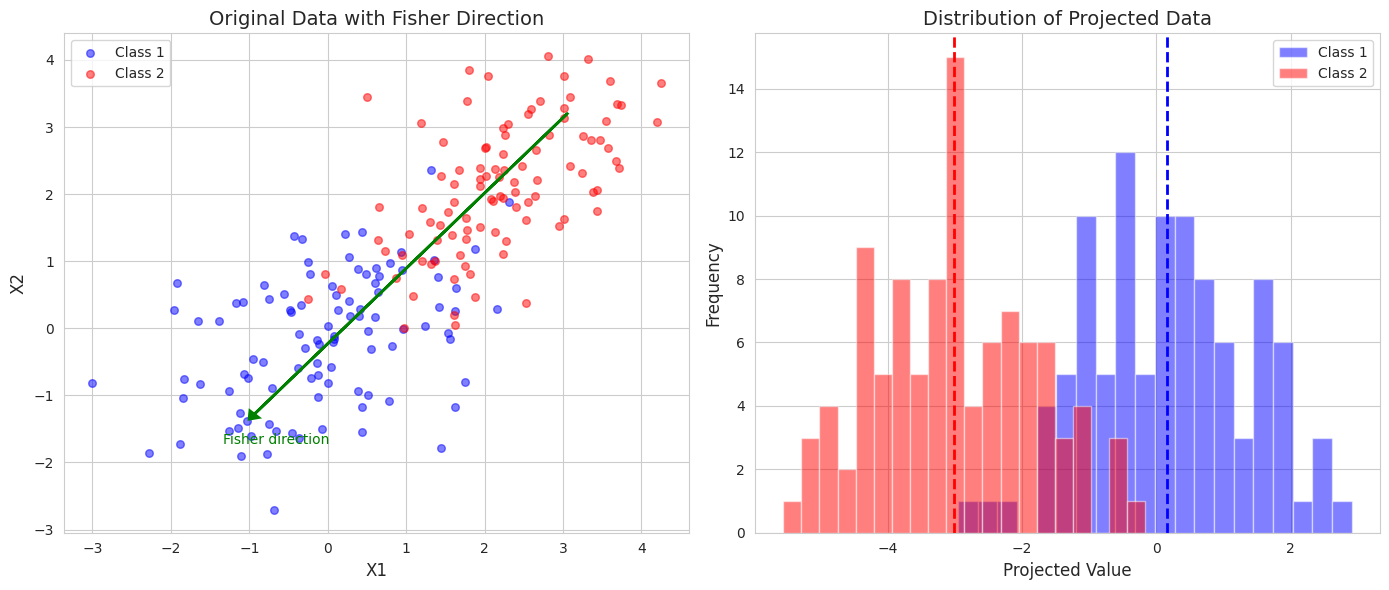


射影後の統計量:
クラス1: 平均 = 0.165, 標準偏差 = 1.197
クラス2: 平均 = -3.007, 標準偏差 = 1.195


In [8]:
# Visualize Fisher's projection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data with projection direction
axes[0].scatter(X1[:, 0], X1[:, 1], c='blue', alpha=0.5, label='Class 1', s=30)
axes[0].scatter(X2[:, 0], X2[:, 1], c='red', alpha=0.5, label='Class 2', s=30)

# Plot projection direction
origin = (np.mean(X, axis=0))
scale = 3
axes[0].arrow(origin[0] - w_fisher[0]*scale, origin[1] - w_fisher[1]*scale,
              w_fisher[0]*scale*2, w_fisher[1]*scale*2,
              head_width=0.15, head_length=0.1, fc='green', ec='green', linewidth=2)
axes[0].text(origin[0] + w_fisher[0]*scale*1.2, origin[1] + w_fisher[1]*scale*1.2,
             'Fisher direction', fontsize=10, color='green')

axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('Original Data with Fisher Direction', fontsize=14)
axes[0].legend()

# Projected data
Z1_proj = X1 @ w_fisher
Z2_proj = X2 @ w_fisher

axes[1].hist(Z1_proj, bins=20, alpha=0.5, label='Class 1', color='blue')
axes[1].hist(Z2_proj, bins=20, alpha=0.5, label='Class 2', color='red')
axes[1].axvline(np.mean(Z1_proj), color='blue', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(Z2_proj), color='red', linestyle='--', linewidth=2)

axes[1].set_xlabel('Projected Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Projected Data', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate separation
print(f"\n射影後の統計量:")
print(f"クラス1: 平均 = {np.mean(Z1_proj):.3f}, 標準偏差 = {np.std(Z1_proj):.3f}")
print(f"クラス2: 平均 = {np.mean(Z2_proj):.3f}, 標準偏差 = {np.std(Z2_proj):.3f}")

## 23.5 分類誤差率

### 誤差の種類
- **訓練誤差**: 訓練データでの誤分類率
- **テスト誤差**: 新しいデータでの誤分類率
- **交差検証誤差**: CVによる誤差推定

### ベイズ誤差率
理論上達成可能な最小誤差率

### 混同行列
|  | 予測: クラス1 | 予測: クラス2 |
|---|---|---|
| 実際: クラス1 | TP | FN |
| 実際: クラス2 | FP | TN |

In [9]:
# 分類誤差の評価
np.random.seed(789)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train LDA
lda_eval = LinearDiscriminantAnalysis()
lda_eval.fit(X_train, y_train)

# Predictions
y_train_pred = lda_eval.predict(X_train)
y_test_pred = lda_eval.predict(X_test)

# Error rates
train_error = 1 - np.mean(y_train_pred == y_train)
test_error = 1 - np.mean(y_test_pred == y_test)

# Cross-validation
cv_scores = cross_val_score(LinearDiscriminantAnalysis(), X, y, cv=5)
cv_error = 1 - np.mean(cv_scores)

print("分類誤差率の評価")
print("="*60)
print(f"\n訓練誤差率: {train_error:.1%}")
print(f"テスト誤差率: {test_error:.1%}")
print(f"5-fold CV誤差率: {cv_error:.1%} (±{np.std(1-cv_scores):.1%})")

分類誤差率の評価

訓練誤差率: 9.3%
テスト誤差率: 6.7%
5-fold CV誤差率: 8.5% (±4.4%)


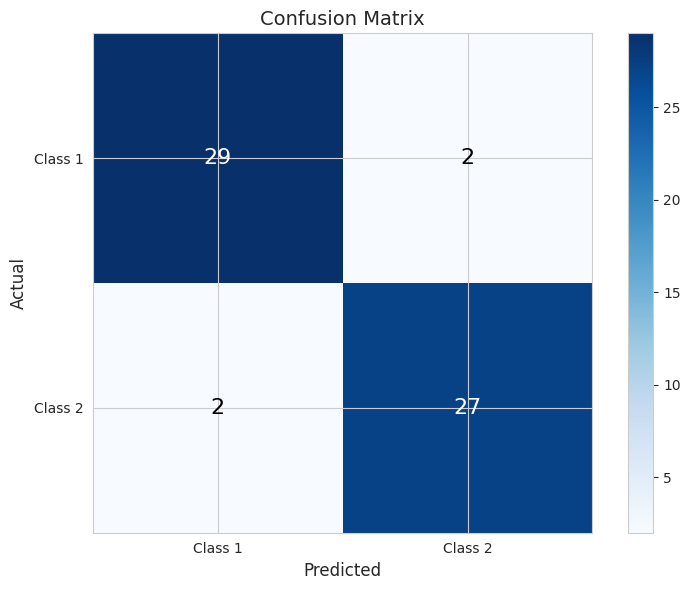


分類レポート:
              precision    recall  f1-score   support

     Class 1       0.94      0.94      0.94        31
     Class 2       0.93      0.93      0.93        29

    accuracy                           0.93        60
   macro avg       0.93      0.93      0.93        60
weighted avg       0.93      0.93      0.93        60



In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Add labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Class 1', 'Class 2'])
ax.set_yticklabels(['Class 1', 'Class 2'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha='center', va='center', 
                       color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16)

plt.colorbar(im)
plt.tight_layout()
plt.show()

# Classification report
print("\n分類レポート:")
print(classification_report(y_test, y_test_pred, target_names=['Class 1', 'Class 2']))

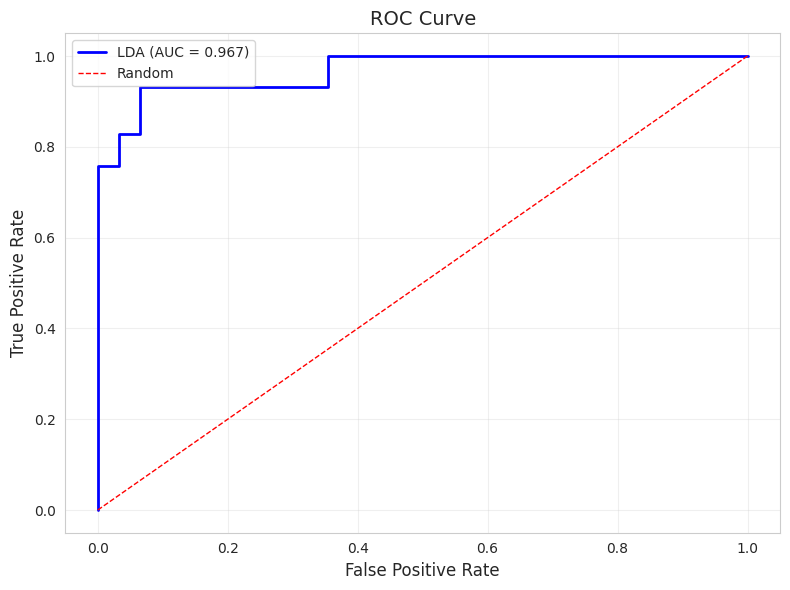

In [11]:
# ROC curve and AUC
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_prob = lda_eval.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'LDA (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 23.6 多クラス判別分析

### 判別関数
クラス $k$ の判別関数:
$$\delta_k(\mathbf{x}) = \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k - \frac{1}{2}\boldsymbol{\mu}_k^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k + \log \pi_k$$

### 判別規則
$\delta_k(\mathbf{x})$ が最大となるクラスに分類

多クラス判別分析 (3クラス)

訓練精度: 88.8%


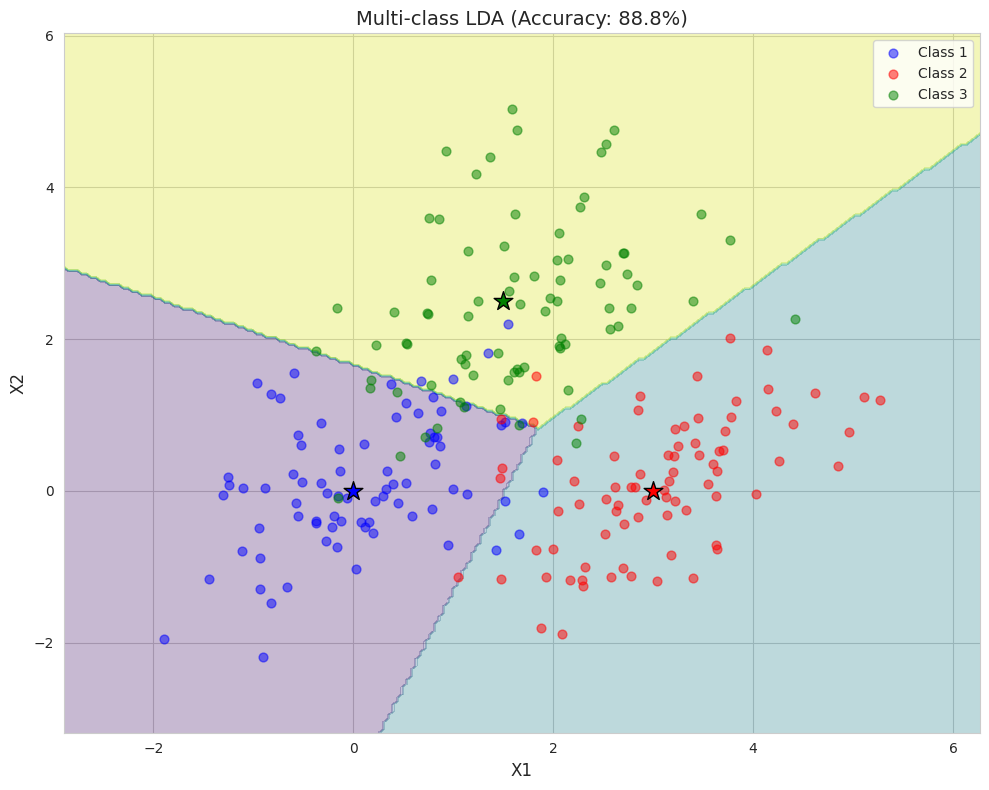

In [12]:
# 多クラス判別分析
np.random.seed(111)

# Generate 3-class data
n_per_class = 80

means = [[0, 0], [3, 0], [1.5, 2.5]]
cov = [[0.8, 0.3], [0.3, 0.8]]

X_multi = []
y_multi = []

for k, mean in enumerate(means):
    X_k = np.random.multivariate_normal(mean, cov, n_per_class)
    X_multi.append(X_k)
    y_multi.extend([k] * n_per_class)

X_multi = np.vstack(X_multi)
y_multi = np.array(y_multi)

print("多クラス判別分析 (3クラス)")
print("="*60)

# Fit LDA
lda_multi = LinearDiscriminantAnalysis()
lda_multi.fit(X_multi, y_multi)

# Accuracy
accuracy_multi = lda_multi.score(X_multi, y_multi)
print(f"\n訓練精度: {accuracy_multi:.1%}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

# Create mesh grid
x_min, x_max = X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1
y_min, y_max = X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on mesh
Z = lda_multi.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
colors = ['blue', 'red', 'green']
for k in range(3):
    mask = y_multi == k
    ax.scatter(X_multi[mask, 0], X_multi[mask, 1], c=colors[k], 
               alpha=0.5, label=f'Class {k+1}', s=40)
    ax.scatter(*means[k], c=colors[k], s=200, marker='*', edgecolor='black')

ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title(f'Multi-class LDA (Accuracy: {accuracy_multi:.1%})', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 23.7 練習問題

### 問題1
2つのクラスのデータ:
- クラス1: 平均 (0, 0), 共分散行列 [[1, 0], [0, 1]]
- クラス2: 平均 (2, 0), 共分散行列 [[1, 0], [0, 1]]

のフィッシャーの判別方向を求めよ。

### 問題2
LDAとQDAの使い分けの基準を説明せよ。

### 問題3
訓練誤差がテスト誤差より小さくなる理由を説明せよ。

In [13]:
# 問題1の解答
print("問題1: フィッシャーの判別方向")
print("="*60)

mu1_p = np.array([0, 0])
mu2_p = np.array([2, 0])
cov_p = np.array([[1, 0], [0, 1]])

# S_W = 2 * cov (for equal-size classes)
# In general, S_W = sum of within-class scatter
# For this example, S_W is proportional to identity matrix

# Fisher direction
# w* = S_W^{-1} (mu1 - mu2)
# With identity covariance, w* is simply (mu1 - mu2)

S_W_p = 2 * cov_p  # Simplified for equal-sized classes
w_p = np.linalg.inv(S_W_p) @ (mu1_p - mu2_p)
w_p = w_p / np.linalg.norm(w_p)

print(f"\nμ_1 = {mu1_p}")
print(f"μ_2 = {mu2_p}")
print(f"\nフィッシャーの判別方向: w = {w_p}")
print("\n解釈: X1軸方向（平均の差の方向）が判別に最も有効")

問題1: フィッシャーの判別方向

μ_1 = [0 0]
μ_2 = [2 0]

フィッシャーの判別方向: w = [-1.  0.]

解釈: X1軸方向（平均の差の方向）が判別に最も有効


In [14]:
# 問題2の解答
print("問題2: LDAとQDAの使い分け")
print("="*60)

print("""
【LDAを使う場合】
1. 各クラスの共分散行列がほぼ等しい
2. サンプルサイズが小さい（推定するパラメータが少ない）
3. 判別境界が線形で十分

【QDAを使う場合】
1. 各クラスの共分散行列が明らかに異なる
2. サンプルサイズが十分大きい
3. より複雑な（二次）判別境界が必要

【判断の実際】
- Boxの M 検定で共分散行列の等質性を検定
- 交差検証で両方試して比較
- 可視化で判別境界を確認
""")

問題2: LDAとQDAの使い分け

【LDAを使う場合】
1. 各クラスの共分散行列がほぼ等しい
2. サンプルサイズが小さい（推定するパラメータが少ない）
3. 判別境界が線形で十分

【QDAを使う場合】
1. 各クラスの共分散行列が明らかに異なる
2. サンプルサイズが十分大きい
3. より複雑な（二次）判別境界が必要

【判断の実際】
- Boxの M 検定で共分散行列の等質性を検定
- 交差検証で両方試して比較
- 可視化で判別境界を確認



In [15]:
# 問題3の解答
print("問題3: 訓練誤差とテスト誤差")
print("="*60)

print("""
【訓練誤差 < テスト誤差 の理由】

1. 過学習 (Overfitting)
   - モデルが訓練データのノイズまで学習
   - 新しいデータに対する汎化能力が低下

2. 楽観的バイアス
   - 同じデータで学習と評価を行う
   - モデルは既に見たデータに最適化されている

3. データの特異性
   - 訓練データが母集団を完全に代表していない
   - テストデータには異なるパターンが含まれる可能性

【対策】
- 交差検証を使用
- 正則化を適用
- モデルの複雑さを制限
""")

問題3: 訓練誤差とテスト誤差

【訓練誤差 < テスト誤差 の理由】

1. 過学習 (Overfitting)
   - モデルが訓練データのノイズまで学習
   - 新しいデータに対する汎化能力が低下

2. 楽観的バイアス
   - 同じデータで学習と評価を行う
   - モデルは既に見たデータに最適化されている

3. データの特異性
   - 訓練データが母集団を完全に代表していない
   - テストデータには異なるパターンが含まれる可能性

【対策】
- 交差検証を使用
- 正則化を適用
- モデルの複雑さを制限



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---